<a href="https://colab.research.google.com/github/mjchav/COSC_4368_Group10/blob/main/Group_10_Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
IMAGE_DIMENSIONS = (x_train.shape[1], x_train.shape[2], x_train.shape[3])
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.models import Sequential

In [ ]:
def plot_curves(history, model_name):
    def plot_loss_curves(history, plot):
        plot.plot(history.history['loss'], label='Train Loss')
        plot.plot(history.history['val_loss'], label='Validation Loss')
        plot.title(f'{model_name}: Training & Validation Loss')
        plot.xlabel('Epoch')
        plot.ylabel('Mean Squared Error (Loss)')
        plot.legend()
        plot.grid(True)

    def plot_accuracy_curves(history, plot):
        plot.plot(history.history['accuracy'], label='Train Accuracy')
        plot.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plot.title(f'{model_name}: Training & Validation Accuracy')
        plot.xlabel('Epoch')
        plot.ylabel('Accuracy')
        plot.legend()
        plot.grid(True)

    plt.figure(figsize=(5,5))
    plot_loss_curves(history, plt)
    plt.show()
    plt.figure(figsize=(5,5))
    plot_accuracy_curves(history, plt)
    plt.show()

## Basic CNN

In [ ]:
basic_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    # The convolution layer detects specific features of an image in every section of the image
    Conv2D(32, 3, padding='same', activation='relu'),
    # Pooling reduces the dimensions of the feature maps from the convolution layer
    MaxPooling2D((2,2)),

    # The number of filters (the first parameter of Conv2D) expand to account for different combinations
    # of features in the deeper parts of the model
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax') # Last dense layer has 10 units for the 10 types of labels
])

In [ ]:
basic_cnn_model.compile(
    optimizer='adam',
    # Sparse categorical crossentropy is used when multiple labels are provided as
    # integers, but not one-hot encoded
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
basic_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# This cell will take about a few minutes to run. If you have more layers or epochs, it could run longer
history_basic_cnn = basic_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4802 - loss: 1.6824 - val_accuracy: 0.5514 - val_loss: 1.2664
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6008 - loss: 1.1324 - val_accuracy: 0.6260 - val_loss: 1.0813
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6514 - loss: 0.9986 - val_accuracy: 0.6660 - val_loss: 0.9780
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6838 - loss: 0.8989 - val_accuracy: 0.6714 - val_loss: 0.9753
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7156 - loss: 0.8155 - val_accuracy: 0.6960 - val_loss: 0.9318
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7374 - loss: 0.7493 - val_accuracy: 0.6890 - val_loss: 0.9588
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7594 - loss: 0.6860 - val_accuracy: 0.6988 - val_loss: 0.9687
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7841 - loss: 0.6208 -

In [ ]:
basic_train_loss = history_basic_cnn.history['loss']
basic_train_accuracy = history_basic_cnn.history['accuracy']
basic_validation_loss = history_basic_cnn.history['val_loss']
basic_validation_accuracy = history_basic_cnn.history['val_accuracy']
basic_test_loss, basic_test_accuracy = basic_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6468 - loss: 1.2377


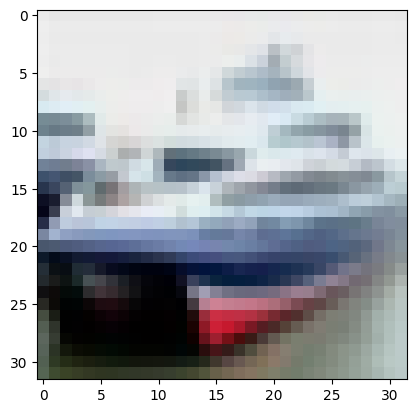

In [ ]:
plt.imshow(x_test[1])

In [ ]:
basic_cnn_predictions = basic_cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print(f"Basic CNN Model")
print(f"Final Train Accuracy: {basic_train_accuracy[len(basic_train_accuracy)-1]:.3f}, Final Train Loss: {basic_train_loss[len(basic_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {basic_validation_accuracy[len(basic_validation_accuracy)-1]:.3f}, Final Validation Loss: {basic_validation_loss[len(basic_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {basic_test_accuracy:.3f}, Test Loss: {basic_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(basic_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

Basic CNN Model
Final Train Accuracy: 0.815, Final Train Loss: 0.534
Final Validation Accuracy: 0.659, Final Validation Loss: 1.193
Test Accuracy: 0.647, Test Loss: 1.238
Example Prediction: ship, Actual = ship


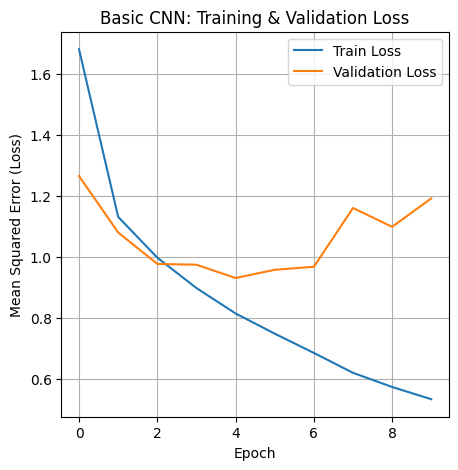

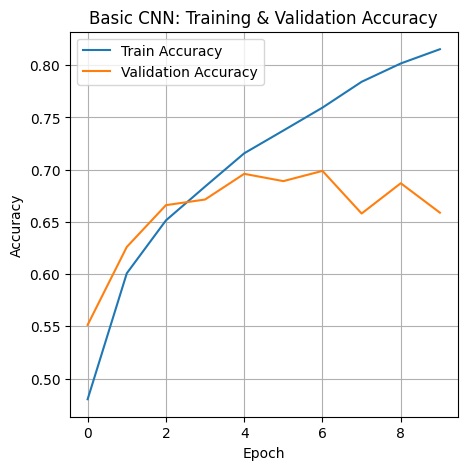

In [ ]:
plot_curves(history_basic_cnn, "Basic CNN")
# Ideally, the train and validation curves should converge smoothly. The validation curve here is unstable and crosses the train curve,
# meaning the model is unstable and likely overfitting.

## CNN with More Layers

In [ ]:
more_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [ ]:
more_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
more_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,386 (2.49 MB)

 Trainable params: 653,386 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_more_cnn = more_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.4706 - loss: 1.5817 - val_accuracy: 0.5832 - val_loss: 1.1846
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.6077 - loss: 1.1174 - val_accuracy: 0.5362 - val_loss: 1.4885
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6606 - loss: 0.9682 - val_accuracy: 0.6402 - val_loss: 1.0248
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6958 - loss: 0.8703 - val_accuracy: 0.6812 - val_loss: 0.9562
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7246 - loss: 0.7964 - val_accuracy: 0.7010 - val_loss: 0.9140
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7470 - loss: 0.7266 - val_accuracy: 0.7042 - val_loss: 0.8903
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7723 - loss: 0.6589 - val_accuracy: 0.7214 - val_loss: 0.8813
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7847 - loss: 0.6121 

In [ ]:
more_train_loss = history_more_cnn.history['loss']
more_train_accuracy = history_more_cnn.history['accuracy']
more_validation_loss = history_more_cnn.history['val_loss']
more_validation_accuracy = history_more_cnn.history['val_accuracy']
more_test_loss, more_test_accuracy = more_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6904 - loss: 1.0398


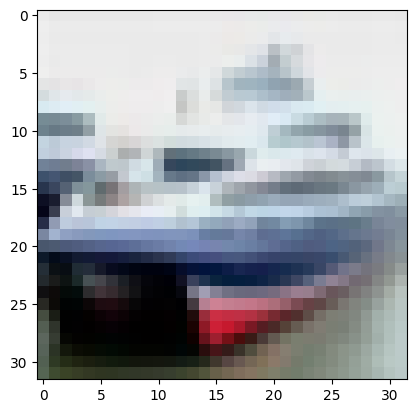

In [ ]:
plt.imshow(x_test[1])

In [ ]:
more_cnn_predictions = more_cnn_model.predict(x_test)
print(f"CNN Model with More Layers")
print(f"Final Train Accuracy: {more_train_accuracy[len(more_train_accuracy)-1]:.3f}, Final Train Loss: {more_train_loss[len(more_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {more_validation_accuracy[len(more_validation_accuracy)-1]:.3f}, Final Validation Loss: {more_validation_loss[len(more_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {more_test_accuracy:.3f}, Test Loss: {more_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(more_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN Model with More Layers
Final Train Accuracy: 0.817, Final Train Loss: 0.525
Final Validation Accuracy: 0.701, Final Validation Loss: 0.997
Test Accuracy: 0.690, Test Loss: 1.040
Example Prediction: ship, Actual = ship


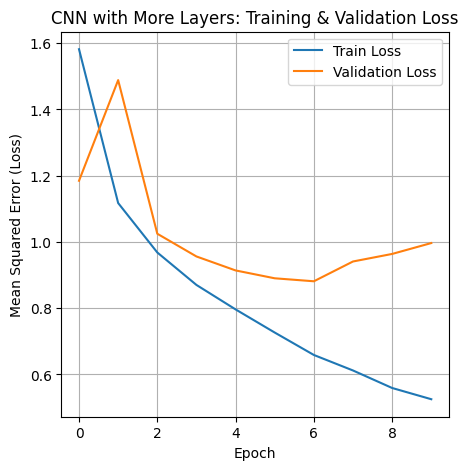

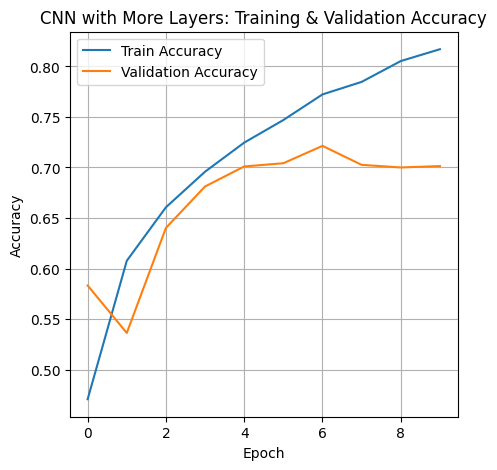

In [ ]:
plot_curves(history_more_cnn, "CNN with More Layers")
# The curves here are even more unstable than the basic CNN. The results are also worse, so adding more layers isn't better here.

## CNN with More Epochs

In [ ]:
epoch_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [ ]:
epoch_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
epoch_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_epoch_cnn = epoch_cnn_model.fit(
    x_train,
    y_train,
    epochs = 20,
    validation_split = 0.1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4788 - loss: 1.6543 - val_accuracy: 0.5946 - val_loss: 1.1502
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6092 - loss: 1.1128 - val_accuracy: 0.6086 - val_loss: 1.0996
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6634 - loss: 0.9665 - val_accuracy: 0.6640 - val_loss: 0.9878
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7000 - loss: 0.8651 - val_accuracy: 0.6692 - val_loss: 0.9863
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7289 - loss: 0.7759 - val_accuracy: 0.6818 - val_loss: 0.9626
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7575 - loss: 0.7005 - val_accuracy: 0.7036 - val_loss: 0.9212
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7844 - loss: 0.6242 - val_accuracy: 0.6920 - val_loss: 0.9908
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8008 - loss: 0.5707 

In [ ]:
epoch_train_loss = history_epoch_cnn.history['loss']
epoch_train_accuracy = history_epoch_cnn.history['accuracy']
epoch_validation_loss = history_epoch_cnn.history['val_loss']
epoch_validation_accuracy = history_epoch_cnn.history['val_accuracy']
epoch_test_loss, epoch_test_accuracy = epoch_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6553 - loss: 1.9921


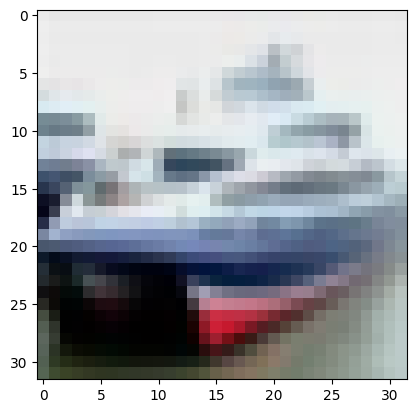

In [ ]:
plt.imshow(x_test[1])

In [ ]:
epoch_cnn_predictions = epoch_cnn_model.predict(x_test)
print(f"CNN Model with More Epochs")
print(f"Final Train Accuracy: {epoch_train_accuracy[len(epoch_train_accuracy)-1]:.3f}, Final Train Loss: {epoch_train_loss[len(epoch_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {epoch_validation_accuracy[len(epoch_validation_accuracy)-1]:.3f}, Final Validation Loss: {epoch_validation_loss[len(epoch_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {epoch_test_accuracy:.3f}, Test Loss: {epoch_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(epoch_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
CNN Model with More Epochs
Final Train Accuracy: 0.911, Final Train Loss: 0.284
Final Validation Accuracy: 0.667, Final Validation Loss: 2.007
Test Accuracy: 0.655, Test Loss: 1.992
Example Prediction: automobile, Actual = ship


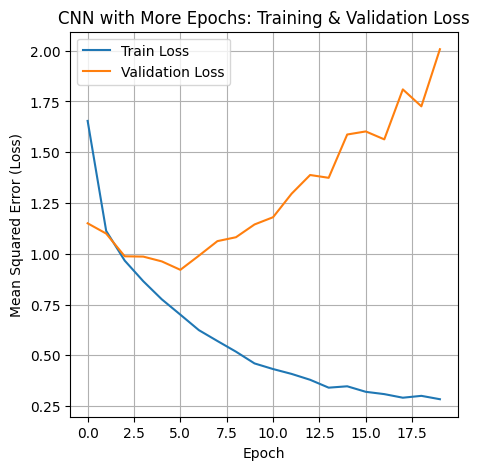

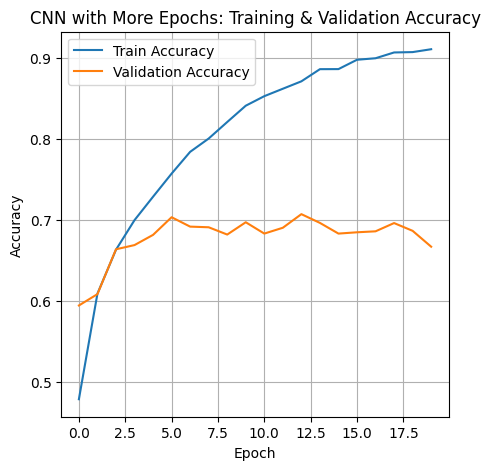

In [ ]:
plot_curves(history_epoch_cnn, "CNN with More Epochs")
# While the resulting accuracies are much better than the basic model, the curves are very unstable
# and the test accuracy is similar to the basic model. So that means 20 epochs could be too many.

## CNN with Dropout

In [ ]:
dropout_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])

In [ ]:
dropout_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
dropout_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_dropout_cnn = dropout_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3601 - loss: 1.8575 - val_accuracy: 0.4466 - val_loss: 1.5256
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4965 - loss: 1.4117 - val_accuracy: 0.5570 - val_loss: 1.2547
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5578 - loss: 1.2521 - val_accuracy: 0.6078 - val_loss: 1.1190
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.5973 - loss: 1.1478 - val_accuracy: 0.6392 - val_loss: 1.0336
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6271 - loss: 1.0786 - val_accuracy: 0.6502 - val_loss: 1.0002
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6478 - loss: 1.0195 - val_accuracy: 0.6516 - val_loss: 1.0020
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6620 - loss: 0.9730 - val_accuracy: 0.6648 - val_loss: 0.9654
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6773 - loss: 0.9378 

In [ ]:
dropout_train_loss = history_dropout_cnn.history['loss']
dropout_train_accuracy = history_dropout_cnn.history['accuracy']
dropout_validation_loss = history_dropout_cnn.history['val_loss']
dropout_validation_accuracy = history_dropout_cnn.history['val_accuracy']
dropout_test_loss, dropout_test_accuracy = dropout_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6546 - loss: 1.0410


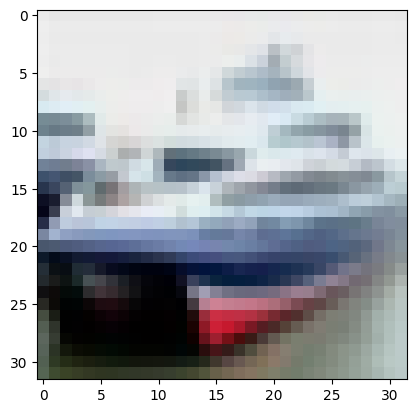

In [ ]:
plt.imshow(x_test[1])

In [ ]:
dropout_cnn_predictions = dropout_cnn_model.predict(x_test)
print(f"CNN Model with Dropout")
print(f"Final Train Accuracy: {dropout_train_accuracy[len(dropout_train_accuracy)-1]:.3f}, Final Train Loss: {dropout_train_loss[len(dropout_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {dropout_validation_accuracy[len(dropout_validation_accuracy)-1]:.3f}, Final Validation Loss: {dropout_validation_loss[len(dropout_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {dropout_test_accuracy:.3f}, Test Loss: {dropout_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(dropout_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
CNN Model with Dropout
Final Train Accuracy: 0.702, Final Train Loss: 0.861
Final Validation Accuracy: 0.666, Final Validation Loss: 1.008
Test Accuracy: 0.655, Test Loss: 1.041
Example Prediction: automobile, Actual = ship


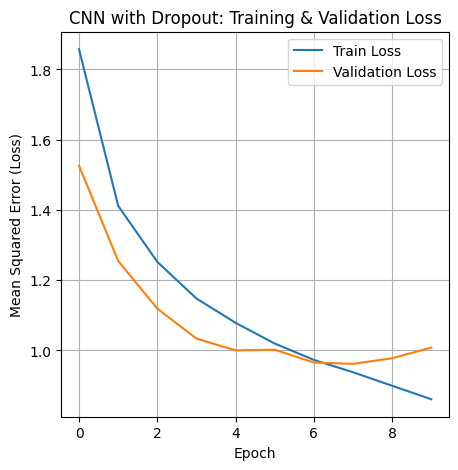

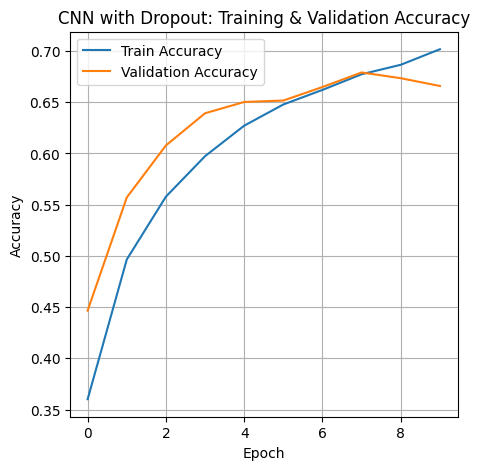

In [ ]:
plot_curves(history_dropout_cnn, "CNN with Dropout")
# While the results are about the same as the basic model, the curves are more stable.
# Adding more dropout layers, perhaps between the convolution and pooling layers could help.
# Doing this with more epochs could yield some better results.

In [ ]:
from keras.layers import BatchNormalization, Rescaling
improved_model_v2 = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Rescaling(1./255),

    Conv2D(32, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

improved_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
improved_model_v2.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_6 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5066 - loss: 1.4622 - val_accuracy: 0.5264 - val_loss: 1.2952
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6550 - loss: 0.9856 - val_accuracy: 0.6996 - val_loss: 0.8763
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7095 - loss: 0.8413 - val_accuracy: 0.7280 - val_loss: 0.7989
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7455 - loss: 0.7324 - val_accuracy: 0.7080 - val_loss: 0.8458
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7702 - loss: 0.6617 - val_accuracy: 0.7166 - val_loss: 0.8345
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7926 - loss: 0.5942 - val_accuracy: 0.7484 - val_loss: 0.7417
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8174 - loss: 0.5238 - val_accuracy: 0.7422 - val_loss: 0.7839
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8336 - loss: 0.4750 -

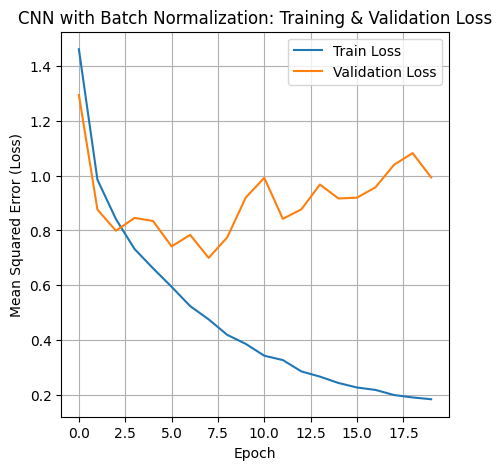

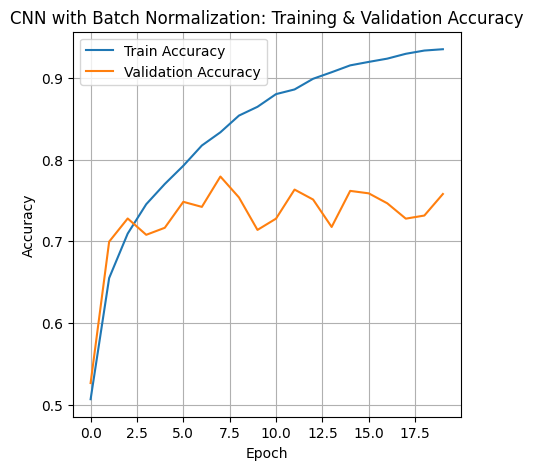

In [ ]:
history_improved_v2 = improved_model_v2.fit(
    x_train,
    y_train,
    epochs=20,
    validation_split=0.1
)

improved_v2_train_loss = history_improved_v2.history['loss']
improved_v2_train_accuracy = history_improved_v2.history['accuracy']
improved_v2_validation_loss = history_improved_v2.history['val_loss']
improved_v2_validation_accuracy = history_improved_v2.history['val_accuracy']
improved_v2_test_loss, improved_v2_test_accuracy = improved_model_v2.evaluate(x_test, y_test)

improved_v2_predictions = improved_model_v2.predict(x_test)
print(f"CNN with Batch Normalization")
print(f"Final Train Accuracy: {improved_v2_train_accuracy[-1]:.3f}, Final Train Loss: {improved_v2_train_loss[-1]:.3f}")
print(f"Final Validation Accuracy: {improved_v2_validation_accuracy[-1]:.3f}, Final Validation Loss: {improved_v2_validation_loss[-1]:.3f}")
print(f"Test Accuracy: {improved_v2_test_accuracy:.3f}, Test Loss: {improved_v2_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(improved_v2_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

plot_curves(history_improved_v2, "CNN with Batch Normalization")